In [27]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/AI/week3/titanic.csv')

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [28]:
df.isnull().sum() #결측치 개수 확인

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [29]:
#결측치가 너무 많아서 평균값 의미 없다 판단
df=df.drop('Cabin',axis=1)

In [30]:
# Age 결측값에 평균값 넣기
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Age']

,Age
0,22.000000
1,38.000000
2,26.000000
3,35.000000
4,35.000000
...,...
886,27.000000
887,19.000000
888,29.699118
889,26.000000


In [31]:
df.isnull().sum() #결측치 개수 확인

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [32]:
#성별은 중요한 feature이기 때문에 남자는 0, 여자는 1로 변환
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

In [33]:
# Embarked의 행 2개는 최빈값으로 널기
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [34]:
# 성별은 2개라 0,1로 나누면 되지만 Embarked는 3개임으로 map이 아닌 원-핫 인코딩으로 변환
# 최빈값이 아닌 평균값을 넣고싶다면 아래 행을 실행 후 평균값 대입 가능
df = pd.get_dummies(df, columns=['Embarked'], dtype=int)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.000000,1,0,A/5 21171,7.2500,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.000000,1,0,PC 17599,71.2833,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",1,26.000000,0,0,STON/O2. 3101282,7.9250,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.000000,1,0,113803,53.1000,0,0,1
4,5,0,3,"Allen, Mr. William Henry",0,35.000000,0,0,373450,8.0500,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.000000,0,0,211536,13.0000,0,0,1
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.000000,0,0,112053,30.0000,0,0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,29.699118,1,2,W./C. 6607,23.4500,0,0,1
889,890,1,1,"Behr, Mr. Karl Howell",0,26.000000,0,0,111369,30.0000,1,0,0


In [35]:
df = df.drop(['Survived', 'PassengerId', 'Name', 'Ticket'], axis=1)
df

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,3,0,22.000000,1,0,7.2500,0,0,1
1,1,1,38.000000,1,0,71.2833,1,0,0
2,3,1,26.000000,0,0,7.9250,0,0,1
3,1,1,35.000000,1,0,53.1000,0,0,1
4,3,0,35.000000,0,0,8.0500,0,0,1
...,...,...,...,...,...,...,...,...,...
886,2,0,27.000000,0,0,13.0000,0,0,1
887,1,1,19.000000,0,0,30.0000,0,0,1
888,3,1,29.699118,1,2,23.4500,0,0,1
889,1,0,26.000000,0,0,30.0000,1,0,0


중요한 값만 X값에 넣기 - Pclass,sex,age,sipsp,parch,fare,embarked 가 의미있으면서 모델에 적용 가능한 값인데 Embarked(항구), Fare(요금)의 경우 Pclass에 의해 중요도가 떨어진다 판단하여 제외

In [36]:
#cabin은 자료가 거의 없음
X = df.drop(['Pclass','Fare','Embarked_C','Embarked_Q','Embarked_S'], axis=1)
y = df['Pclass']
X

,Sex,Age,SibSp,Parch
0,0,22.000000,1,0
1,1,38.000000,1,0
2,1,26.000000,0,0
3,1,35.000000,1,0
4,0,35.000000,0,0
...,...,...,...,...
886,0,27.000000,0,0
887,1,19.000000,0,0
888,1,29.699118,1,2
889,0,26.000000,0,0


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25,random_state=0)

In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)
ly_preds = model.predict(X_test)

print('평균제곱오차', mean_squared_error(ly_preds, y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱오차', mse_np(ly_preds, y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱오차', mse(ly_preds, y_test))

평균제곱오차 0.6035324102540612
평균제곱오차 0.6035324102540612
평균제곱오차 0.6035324102540612


In [39]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(random_state=0)
model.fit(X_train, y_train)
ly_preds = model.predict(X_test)

print('평균제곱오차', mean_squared_error(ly_preds, y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱오차', mse_np(ly_preds, y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱오차', mse(ly_preds, y_test))

평균제곱오차 0.7797792079691239
평균제곱오차 0.7797792079691239
평균제곱오차 0.7797792079691238


In [40]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=0)
model.fit(X_train, y_train)
ly_preds = model.predict(X_test)

print('평균제곱오차', mean_squared_error(ly_preds, y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱오차', mse_np(ly_preds, y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱오차', mse(ly_preds, y_test))

평균제곱오차 0.6452828068444998
평균제곱오차 0.6452828068444998
평균제곱오차 0.6452828068444997


In [41]:
from sklearn.neighbors import KNeighborsRegressor

Ti_knn = KNeighborsRegressor(n_neighbors=5)
Ti_knn.fit(X_train, y_train)

pred_knn = Ti_knn.predict(X_test)

print ("\n--- KNeighborsRegressor ---")

print('평균제곱오차', mean_squared_error(pred_knn, y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱오차', mse_np(pred_knn, y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱오차', mse(pred_knn, y_test))


--- KNeighborsRegressor ---
평균제곱오차 0.6721076233183856
평균제곱오차 0.6721076233183856
평균제곱오차 0.6721076233183855


In [42]:
# K값의 최적값을 찾기 위해 for문을 1~30까지 돌리고 그래프로 표현 Regression 에서는 MSE 값이 가장 작은값이 최적값


--- KNeighborsRegressor ---
최적의 k: 19
최소 평균제곱오차: 0.6114057861197719
평균제곱오차(sklearn) 0.6114057861197719
평균제곱오차(numpy) 0.6114057861197719
평균제곱오차(직접구현) 0.6114057861197714


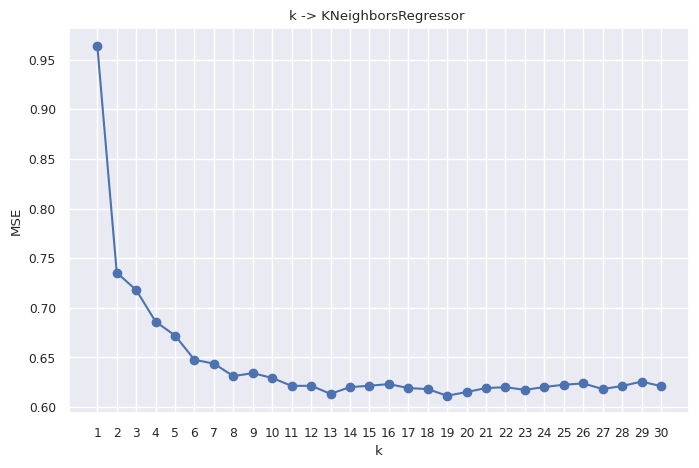

In [43]:
import matplotlib.pyplot as plt

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

k_list = []
mse_list = []

#최적 k값 찾기
for k in range(1, 31):
    Ti_knn = KNeighborsRegressor(n_neighbors=k)
    Ti_knn.fit(X_train, y_train)

    pred_knn = Ti_knn.predict(X_test)

    error = mean_squared_error(y_test, pred_knn)

    k_list.append(k)
    mse_list.append(error)

best_k = k_list[np.argmin(mse_list)]
best_mse = min(mse_list)

print("\n--- KNeighborsRegressor ---")
print("최적의 k:", best_k)
print("최소 평균제곱오차:", best_mse)

# 최적 k로 다시 예측
best_model = KNeighborsRegressor(n_neighbors=best_k)
best_model.fit(X_train, y_train)
pred_knn = best_model.predict(X_test)

print('평균제곱오차(sklearn)', mean_squared_error(y_test, pred_knn))
print('평균제곱오차(numpy)', mse_np(y_test, pred_knn))
print('평균제곱오차(직접구현)', mse(y_test, pred_knn))

plt.figure(figsize=(8, 5))
plt.plot(k_list, mse_list, marker='o')
plt.xlabel("k")
plt.ylabel("MSE")
plt.title("k -> KNeighborsRegressor ")
plt.xticks(range(1, 31))
plt.grid(True)
plt.show()

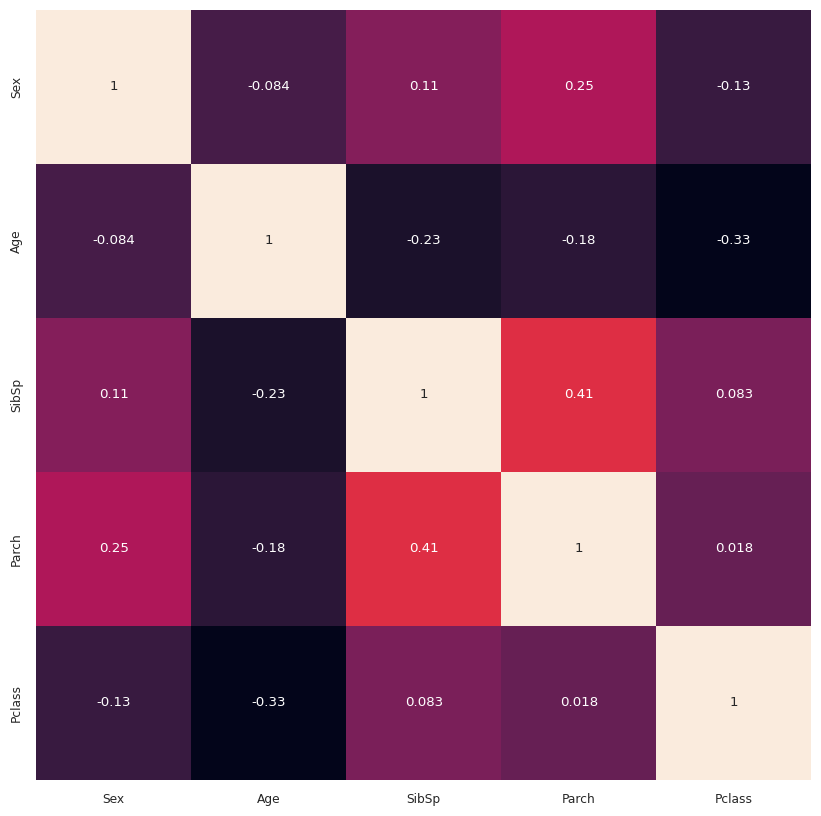

In [44]:
import seaborn as sns

#상관 관계 행렬
# 0.3 이상인 경우 상관관계가 있고, 0.7이상이면 아주 높음
corr_df = pd.concat([X, y], axis=1)
df_corr = corr_df.corr()

#히트맵
plt.figure(figsize=(10,10))
sns.set(font_scale=0.8)
sns.heatmap(df_corr, annot=True, cbar=False)
plt.show()

# PRICE와 높은 건  MedInc

아래는 다 넣은거

In [45]:
#class,sex,age,sipsp,parch,fare,embarked
#cabin은 자료가 거의 없음
X = df.drop(['Pclass'], axis=1)
y = df['Pclass']

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25,random_state=0)

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)
ly_preds = model.predict(X_test)

print('평균제곱오차', mean_squared_error(ly_preds, y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱오차', mse_np(ly_preds, y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱오차', mse(ly_preds, y_test))

평균제곱오차 0.36755488683248505
평균제곱오차 0.36755488683248505
평균제곱오차 0.36755488683248505


In [48]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(random_state=0)
model.fit(X_train, y_train)
ly_preds = model.predict(X_test)

print('평균제곱오차', mean_squared_error(ly_preds, y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱오차', mse_np(ly_preds, y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱오차', mse(ly_preds, y_test))

평균제곱오차 0.0704932735426009
평균제곱오차 0.0704932735426009
평균제곱오차 0.07049327354260089


In [49]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=0)
model.fit(X_train, y_train)
ly_preds = model.predict(X_test)

print('평균제곱오차', mean_squared_error(ly_preds, y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱오차', mse_np(ly_preds, y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱오차', mse(ly_preds, y_test))

평균제곱오차 0.0576563763345778
평균제곱오차 0.0576563763345778
평균제곱오차 0.0576563763345778


In [50]:
from sklearn.neighbors import KNeighborsRegressor

Ti_knn = KNeighborsRegressor(n_neighbors=5)
Ti_knn.fit(X_train, y_train)

pred_knn = Ti_knn.predict(X_test)

print ("\n--- KNeighborsRegressor ---")

print('평균제곱오차', mean_squared_error(pred_knn, y_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱오차', mse_np(pred_knn, y_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱오차', mse(pred_knn, y_test))


--- KNeighborsRegressor ---
평균제곱오차 0.12556053811659193
평균제곱오차 0.12556053811659193
평균제곱오차 0.1255605381165919



--- KNeighborsRegressor ---
최적의 k: 4
최소 평균제곱오차: 0.12051569506726457
평균제곱오차(sklearn) 0.12051569506726457
평균제곱오차(numpy) 0.12051569506726457
평균제곱오차(직접구현) 0.12051569506726457


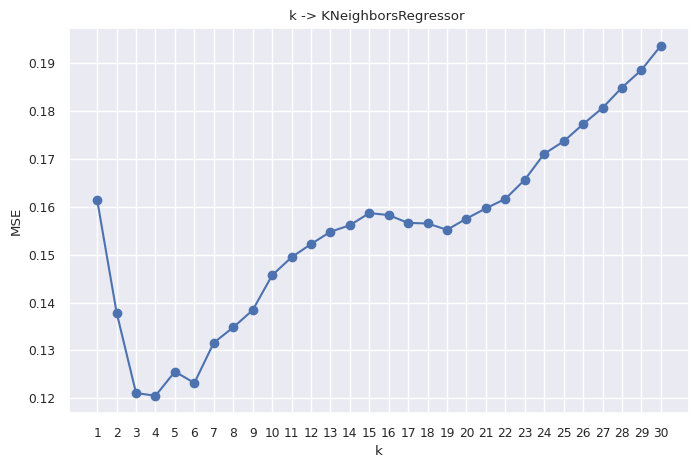

In [51]:
import matplotlib.pyplot as plt

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

k_list = []
mse_list = []

#최적 k값 찾기
for k in range(1, 31):
    Ti_knn = KNeighborsRegressor(n_neighbors=k)
    Ti_knn.fit(X_train, y_train)

    pred_knn = Ti_knn.predict(X_test)

    error = mean_squared_error(y_test, pred_knn)

    k_list.append(k)
    mse_list.append(error)

best_k = k_list[np.argmin(mse_list)]
best_mse = min(mse_list)

print("\n--- KNeighborsRegressor ---")
print("최적의 k:", best_k)
print("최소 평균제곱오차:", best_mse)

# 최적 k로 다시 예측
best_model = KNeighborsRegressor(n_neighbors=best_k)
best_model.fit(X_train, y_train)
pred_knn = best_model.predict(X_test)

print('평균제곱오차(sklearn)', mean_squared_error(y_test, pred_knn))
print('평균제곱오차(numpy)', mse_np(y_test, pred_knn))
print('평균제곱오차(직접구현)', mse(y_test, pred_knn))

plt.figure(figsize=(8, 5))
plt.plot(k_list, mse_list, marker='o')
plt.xlabel("k")
plt.ylabel("MSE")
plt.title("k -> KNeighborsRegressor ")
plt.xticks(range(1, 31))
plt.grid(True)
plt.show()

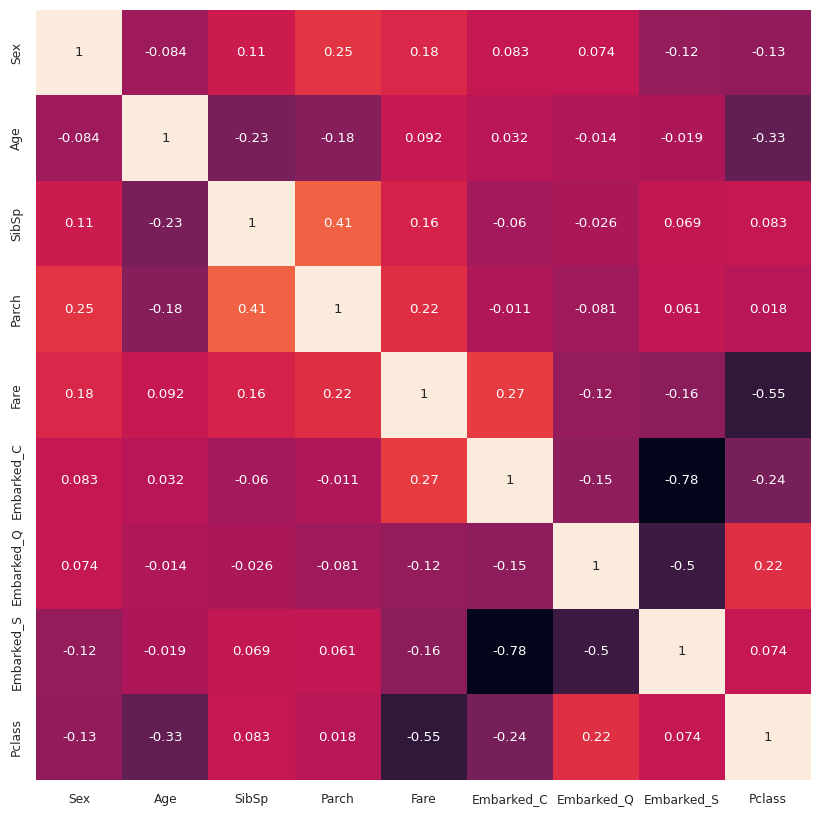

In [52]:
import seaborn as sns

#상관 관계 행렬
# 0.3 이상인 경우 상관관계가 있고, 0.7이상이면 아주 높음
corr_df = pd.concat([X, y], axis=1)
df_corr = corr_df.corr()

#히트맵
plt.figure(figsize=(10,10))
sns.set(font_scale=0.8)
sns.heatmap(df_corr, annot=True, cbar=False)
plt.show()

# PRICE와 높은 건  MedInc